# Stephenson + COMBAT integration: patient-level representations end-to-end

This is a self-contained walkthrough of running [`patpy`](https://github.com/lueckenlab/patpy) on the harmonised **Stephenson + COMBAT** COVID-19 cohort. It builds seven sample-level representations of the same 251 donors, packs them all into one `meta_adata`, and benchmarks them with patpy metrics: KNN scoring (clinical info retention + batch mixing), diffusion-pseudotime correlation with severity, leiden clustering ARI against `Site` and `Status`, gene + cell-type-proportion correlation with pseudotime, and per-cluster marker genes.

| `meta_adata` slot | method | role |
|---|---|---|
| `.X` / `obsm["X_pseudobulk_lognorm"]` | mean pseudobulk on log-normalised counts (`patpy.tl.Pseudobulk`) | baseline |
| `obsm["X_pseudobulk_scanvi"]`         | mean pseudobulk on the dataset-shipped scANVI embedding | latent baseline |
| `obsm["X_composition_clr"]`           | `patpy.tl.CellGroupComposition(apply_clr=True)` | SETA-style composition |
| `obsm["X_gloscope_py"]`               | `patpy.tl.GloScope_py(use_gpu=True)` (RAPIDS cuML on GPU) | symmetric-KL distance, MDS-embedded |
| `obsm["X_sampleclr_ssl"]`             | `sampleclr.ContrastiveModel.pretrain` | self-supervised (lueckenlab/SampleCLR) |
| `obsm["X_sampleclr_ft"]`              | `.fine_tune` on `severity_idx` | same model, supervised head |
| `obsm["X_pascient"]`                  | `patpy.tl.PaSCient` trained from scratch | hierarchical encoder |

Outputs (under `data/stephenson_combat/`):
- `stephenson_combat_meta_adata.h5ad` — final AnnData with every embedding, pairwise distance matrix, per-rep neighbor graph + UMAP, leiden clusters, pseudotime, and benchmark tables.
- `models/sampleclr_{ssl,ft}_state.pt`, `models/pascient_state.pt` — model checkpoints.
- `benchmark_knn_scores.csv`, `benchmark_trajectory_correlation.csv`, `benchmark_clustering_ari.csv`.


In [1]:
# One-time installs (uncomment if missing). Notebook expects the most
# recent patpy and sampleclr available on GitHub.
# %pip install -U "git+https://github.com/lueckenlab/patpy.git@main"
# %pip install -U "git+https://github.com/lueckenlab/SampleCLR.git@main"
# %pip install git+https://github.com/genentech/pascient.git@main
# %pip install "cupy-cuda12x" "cuml-cu12"   # GPU GloScope_py only


In [2]:
import gc
import json
from pathlib import Path

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import torch

import patpy
import sampleclr
from sampleclr import ContrastiveModel
from sampleclr.utils import get_sample_representations_from_adata

print("patpy     :", patpy.__version__)
print("sampleclr :", sampleclr.__version__)
print("scanpy    :", sc.__version__)
print("anndata   :", ad.__version__)
print("torch     :", torch.__version__, "  cuda?", torch.cuda.is_available())

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DATA_DIR = Path("/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat")
MODELS_DIR = DATA_DIR / "models"
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print("DATA_DIR   :", DATA_DIR)


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


patpy     : 0.14.0
sampleclr : 0.1.0
scanpy    : 1.12
anndata   : 0.12.10
torch     : 2.10.0+cu128   cuda? True
DATA_DIR   : /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat


/localscratch/vladimir.shitov/ipykernel_72276/2906975203.py:20: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("scanpy    :", sc.__version__)
/localscratch/vladimir.shitov/ipykernel_72276/2906975203.py:21: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  print("anndata   :", ad.__version__)


## 1. Load the integrated COVID-19 dataset


In [3]:
adata, info = patpy.datasets.combat_stephenson(return_dataset_info=True)
adata.obsm["X_umap"] = adata.obsm["X_umap_scANVI_dataset"]
print(adata)
print("layers:", list(adata.layers))
print("sample_key   :", info.sample_key, " cell_type_key:", info.cell_type_key)
print("n_samples    :", adata.obs[info.sample_key].nunique())


AnnData object with n_obs × n_vars = 1399435 × 1856
    obs: 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', '_scvi_batch', '_scvi_labels', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'split', 'cell_coarse_aligned', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'dataset', 'sample_id', 'Status_encoded', 'leiden'
    uns: 'Site_colors', 'X_scVI_neighbors', 'X_umap_scANVI_dataset', 'X_umap_scVI', '_scvi_manager_uuid', '_scvi_uuid', 'cell_coarse_aligned_colors', 'dataset_colors', 'leiden', 'leiden_colors', 'neighbors', 'scANVI_neighbors_dataset', 'severity_ord_colors', 'umap'
    obsm: 'X_pca', 'X_scANVI', 'X_scANVI_batch', 'X_scANVI_dataset', 'X_scANVI_sample', 'X_scVI', 'X_scVI_batch',

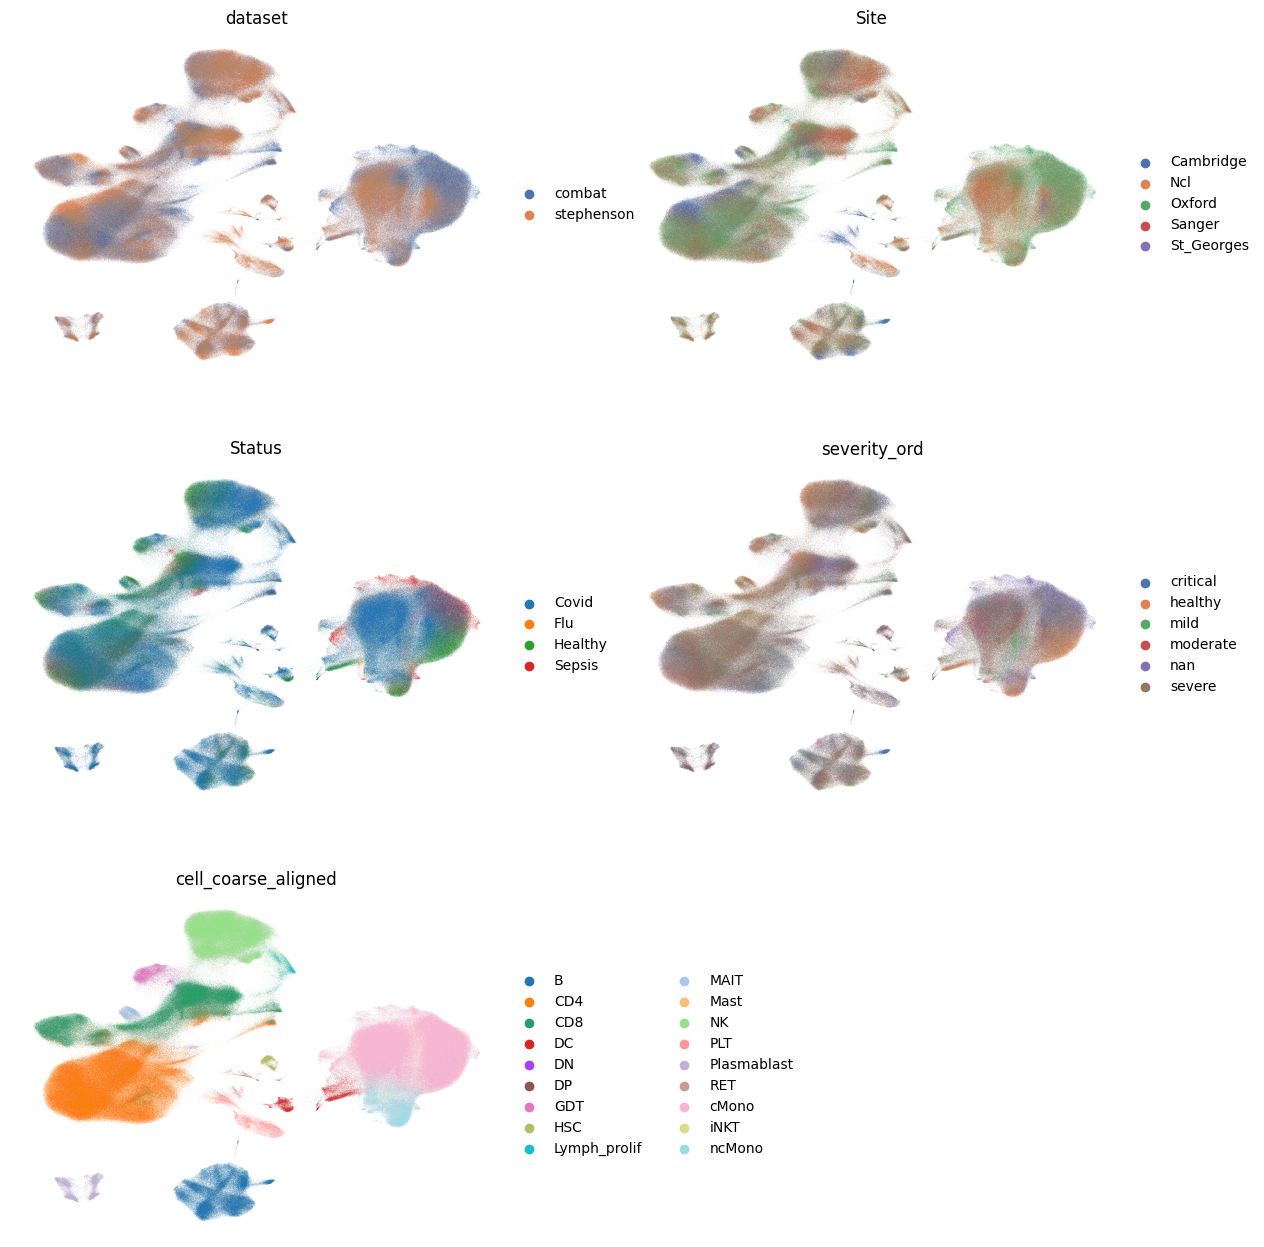

In [4]:
sc.pl.umap(
    adata,
    color=["dataset", "Site", "Status", "severity_ord", "cell_coarse_aligned"],
    frameon=False, ncols=2,
)


## 2. Preprocess raw counts

Normalise to 10 k UMIs and `log1p`. The log-normalised matrix becomes `adata.X`; raw counts move to `adata.layers["counts"]` so any count-based method can still pick them up.


In [5]:
RAW_LAYER     = "X_raw_counts"
LOGNORM_LAYER = "X_log1p"
SCANVI_OBSM   = "X_scANVI_dataset"

adata.layers["counts"] = adata.layers[RAW_LAYER]
adata.X = adata.layers[RAW_LAYER].copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.layers[LOGNORM_LAYER] = adata.X
print("X is log-normalised: max =", float(adata.X.max()), " min =", float(adata.X.min()))


X is log-normalised: max = 9.158218383789062  min = 0.0


## 3. Sample-level metadata + train / val / test split


In [6]:
metadata = patpy.pp.extract_metadata(
    adata, sample_key=info.sample_key, columns=info.sample_metadata_columns,
)
rng = np.random.default_rng(SEED)
metadata["split"] = rng.choice(["train", "val", "test"], size=len(metadata), p=[0.5, 0.25, 0.25])
print(metadata["split"].value_counts())
metadata.head()


split
train    127
test      62
val       62
Name: count, dtype: int64


,dataset,Site,SARSCoV2PCR,Outcome,TimeSinceOnset,split,Status,severity_ord,severity_idx,outcome_bin,Status_encoded
sample_id,,,,,,,,,,,
S00109-Ja001E-PBCa,combat,Oxford,1,2.0,12.0,test,Covid,severe,3,0.0,0.0
S00112-Ja003E-PBCa,combat,Oxford,1,5.0,12.0,train,Covid,mild,1,0.0,0.0
S00005-Ja005E-PBCa,combat,Oxford,1,2.0,14.0,test,Covid,critical,4,0.0,0.0
S00061-Ja003E-PBCa,combat,Oxford,1,4.0,6.0,val,Covid,severe,3,0.0,0.0
S00056-Ja003E-PBCa,combat,Oxford,1,3.0,23.0,train,Covid,severe,3,0.0,0.0


## 4. Two pseudobulk baselines + CLR composition


In [7]:
def mean_pseudobulk(adata, info, *, layer):
    pb = patpy.tl.Pseudobulk(
        sample_key=info.sample_key,
        cell_group_key=info.cell_type_key,
        layer=layer, seed=SEED,
    )
    pb.prepare_anndata(adata)
    pb.calculate_distance_matrix(force=True)
    return pd.DataFrame(np.asarray(pb.sample_representation), index=list(pb.samples))

pb_lognorm = mean_pseudobulk(adata, info, layer=LOGNORM_LAYER)
pb_scanvi  = mean_pseudobulk(adata, info, layer=SCANVI_OBSM)
print("pseudobulk_lognorm:", pb_lognorm.shape, " pseudobulk_scanvi:", pb_scanvi.shape)


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/sample_representation.py:1316: UserWarning: Using data from adata.layers['X_log1p']
  data = self._get_data()


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/sample_representation.py:1316: UserWarning: Using data from adata.obsm['X_scANVI_dataset']
  data = self._get_data()


pseudobulk_lognorm: (251, 1856)  pseudobulk_scanvi: (251, 30)


In [8]:
cmp = patpy.tl.CellGroupComposition(
    sample_key=info.sample_key,
    cell_group_key=info.cell_type_key,
    apply_clr=True, seed=SEED,
)
cmp.prepare_anndata(adata)
cmp.calculate_distance_matrix(force=True)
comp_clr = pd.DataFrame(np.asarray(cmp.sample_representation), index=list(cmp.sample_representation.index))
print("composition_clr:", comp_clr.shape)


composition_clr: (251, 18)


In [9]:
# meta_adata.X = mean pseudobulk on log-norm counts (the baseline)
sample_order = list(metadata.index)
pb_lognorm = pb_lognorm.reindex(sample_order)

meta_adata = ad.AnnData(
    X=pb_lognorm.values.astype(np.float32),
    obs=metadata,
    var=pd.DataFrame(index=adata.var_names),
)
meta_adata.layers["pseudobulk_lognorm"] = meta_adata.X
meta_adata.uns["sample_key"] = info.sample_key
meta_adata.uns["cell_type_key"] = info.cell_type_key

def attach(meta_adata, key, df):
    aligned = df.reindex(list(meta_adata.obs_names))
    if aligned.isna().any().any():
        raise ValueError(f"{key}: missing samples")
    meta_adata.obsm[key] = aligned.values.astype(np.float32)

attach(meta_adata, "X_pseudobulk_lognorm", pb_lognorm)
attach(meta_adata, "X_pseudobulk_scanvi",  pb_scanvi)
attach(meta_adata, "X_composition_clr",    comp_clr)
meta_adata


AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded'
    uns: 'sample_key', 'cell_type_key'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr'
    layers: 'pseudobulk_lognorm'

## 5. SampleCLR — self-supervised pretrain + supervised fine-tune

`sampleclr.ContrastiveModel` is trained on the scANVI embedding with a `Site`-aware sampler. Snapshot the projector after pretrain (SSL embedding), then fine-tune with a `severity_idx` classification head and snapshot again. Best states are persisted to disk.


In [10]:
SAMPLECLR_LAYER = SCANVI_OBSM
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

sclr = ContrastiveModel(
    adata,
    sample_key=info.sample_key,
    layer=SAMPLECLR_LAYER,
    n_cells_per_sample=[500, 750],
    tasks={"classification": ["severity_idx"]},
    use_batch_aware_sampler=True,
    batch_sampler_batch_col="Site",
    train_ids=metadata[metadata["split"] == "train"].index,
    val_ids=metadata[metadata["split"] == "val"].index,
    early_stopping_patience=50,
    batch_size=16,
    contrastive_loss_temperature=0.3,
    attention_sparsity_lambda=0,
)

best_state_ssl, best_val_ssl, epochs_ssl = sclr.pretrain()
print(f"SSL best_val_loss={best_val_ssl:.4f}  epochs={epochs_ssl}")
if best_state_ssl is not None:
    sclr.load_model(best_state_ssl)
    torch.save(best_state_ssl, MODELS_DIR / "sampleclr_ssl_state.pt")
    print("saved sampleclr_ssl_state.pt")


device: cuda


Stage 1: Contrastive-only training (pretrain)


Epoch 1/100 - Loss: 1.5888, Contr: 1.5888, Top1: 1.000, Top5: 1.000 | Time: 0.81s (16 batches, 40.1ms/batch)
Full Loss Report:
contrastive – train: 1.5888 – val: 3.2621
classification (severity_idx) – train: 0.0000 – val: 3.5910
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 2/100 - Loss: 1.4921, Contr: 1.4921, Top1: 1.000, Top5: 1.000 | Time: 0.28s (16 batches, 7.5ms/batch)
Full Loss Report:
contrastive – train: 1.4921 – val: 2.1268
classification (severity_idx) – train: 0.0000 – val: 3.6147
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 3/100 - Loss: 1.2433, Contr: 1.2433, Top1: 1.000, Top5: 1.000 | Time: 0.27s (16 batches, 7.4ms/batch)
Full Loss Report:
contrastive – train: 1.2433 – val: 1.5448
classification (severity_idx) – train: 0.0000 – val: 3.6337
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


...

Epoch 61/100 - Loss: 0.6655, Contr: 0.6655, Top1: 1.000, Top5: 1.000 | Time: 0.27s (16 batches, 7.3ms/batch)
Full Loss Report:
contrastive – train: 0.6655 – val: 1.1440
classification (severity_idx) – train: 0.0000 – val: 3.5980
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 62/100 - Loss: 0.6658, Contr: 0.6658, Top1: 1.000, Top5: 1.000 | Time: 0.27s (16 batches, 7.4ms/batch)
Full Loss Report:
contrastive – train: 0.6658 – val: 1.1685
classification (severity_idx) – train: 0.0000 – val: 3.6053
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 63/100 - Loss: 0.6645, Contr: 0.6645, Top1: 1.000, Top5: 1.000 | Time: 0.27s (16 batches, 7.3ms/batch)
Full Loss Report:
contrastive – train: 0.6645 – val: 1.1474
classification (severity_idx) – train: 0.0000 – val: 3.6372
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 64/100 - Loss: 0.6677, Contr: 0.6677, Top1: 1.000, Top5: 1.000 | Time: 0.28s (16 batches, 7.5ms/batch)
Full Loss Report:
contrastive – train: 0.6677 – val: 1.2005
classification (severity_idx) – train: 0.0000 – val: 3.6074
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000


Epoch 65/100 - Loss: 0.6689, Contr: 0.6689, Top1: 1.000, Top5: 1.000 | Time: 0.28s (16 batches, 7.5ms/batch)
Early stopping triggered in pretrain.
SSL best_val_loss=1.1424  epochs=65
saved sampleclr_ssl_state.pt


In [11]:
sclr_ssl = get_sample_representations_from_adata(
    projector=sclr.projector, aggregator=sclr.aggregator, adata=adata,
    sample_key=info.sample_key, layer=SAMPLECLR_LAYER, subset_size=750,
    meta_obs_names=metadata.index, device=device,
)
sclr_ssl = pd.DataFrame(np.asarray(sclr_ssl), index=list(metadata.index))
attach(meta_adata, "X_sampleclr_ssl", sclr_ssl)
print("sampleclr_ssl:", sclr_ssl.shape)
gc.collect()


sampleclr_ssl: (251, 128)


10602

In [12]:
best_state_ft, best_val_ft, epochs_ft = sclr.fine_tune(val_metric="loss")
print(f"FT  best_val_loss={best_val_ft:.4f}  epochs={epochs_ft}")
if best_state_ft is not None:
    sclr.load_model(best_state_ft)
    torch.save(best_state_ft, MODELS_DIR / "sampleclr_ft_state.pt")
    print("saved sampleclr_ft_state.pt")

(MODELS_DIR / "sampleclr_config.json").write_text(json.dumps({
    "sample_key": info.sample_key, "layer": SAMPLECLR_LAYER,
    "label": "severity_idx", "site_col": "Site",
    "n_cells_per_sample": [500, 750], "batch_size": 16,
    "early_stopping_patience": 50, "contrastive_loss_temperature": 0.3,
    "stats": {"ssl": {"best_val_loss": float(best_val_ssl), "epochs": int(epochs_ssl)},
              "ft":  {"best_val_loss": float(best_val_ft),  "epochs": int(epochs_ft)}},
}, indent=2))


Stage joint: training (fine_tune)
Freezing the backbone for 10 epochs



Epoch 1/100 | Time: 0.22s (16 batches, 4.1ms/batch)
contrastive – train: 0.6665 – val: 1.1643
classification (severity_idx) – train: 3.6572 – val: 3.5977
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 2/100 | Time: 0.22s (16 batches, 4.1ms/batch)
contrastive – train: 0.6604 – val: 1.1511
classification (severity_idx) – train: 3.6479 – val: 3.6168
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 3/100 | Time: 0.23s (16 batches, 4.3ms/batch)
contrastive – train: 0.6666 – val: 1.2116
classification (severity_idx) – train: 3.6334 – val: 3.5774
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 4/100 | Time: 0.22s (16 batches, 4.1ms/batch)
contrastive – train: 0.6660 – val: 1.1859
classification (severity_idx) – train: 3.6357 – val: 3.5996
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------


...


Epoch 82/100 | Time: 0.32s (16 batches, 9.5ms/batch)
contrastive – train: 0.6572 – val: 1.1760
classification (severity_idx) – train: 0.4871 – val: 2.7103
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 83/100 | Time: 0.32s (16 batches, 9.4ms/batch)
contrastive – train: 0.6575 – val: 1.1786
classification (severity_idx) – train: 0.3703 – val: 2.6612
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 84/100 | Time: 0.30s (16 batches, 9.1ms/batch)
contrastive – train: 0.6550 – val: 1.1846
classification (severity_idx) – train: 0.3349 – val: 2.7114
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------



Epoch 85/100 | Time: 0.30s (16 batches, 9.1ms/batch)
contrastive – train: 0.6567 – val: 1.1580
classification (severity_idx) – train: 0.4041 – val: 2.7050
contrastive top1 acc – train: 1.0000 – val: 1.0000
contrastive top5 acc – train: 1.0000 – val: 1.0000
------------------------------
Early stopping triggered in fine_tune.
FT  best_val_loss=1.1399  epochs=85
saved sampleclr_ft_state.pt


429

In [13]:
sclr_ft = get_sample_representations_from_adata(
    projector=sclr.projector, aggregator=sclr.aggregator, adata=adata,
    sample_key=info.sample_key, layer=SAMPLECLR_LAYER, subset_size=750,
    meta_obs_names=metadata.index, device=device,
)
sclr_ft = pd.DataFrame(np.asarray(sclr_ft), index=list(metadata.index))
attach(meta_adata, "X_sampleclr_ft", sclr_ft)
print("sampleclr_ft:", sclr_ft.shape)
gc.collect()


sampleclr_ft: (251, 128)


4104

## 6. GloScope_py — symmetric-KL on scANVI (GPU when available)

GPU path uses RAPIDS `cuml.NearestNeighbors`. CPU fallback uses `pynndescent`. We feed it the scANVI embedding so distances are comparable across cohorts, then take a 30-D MDS embedding.


In [14]:
def gloscope_check_gpu():
    try:
        import cuml, cupy  # noqa: F401
        return torch.cuda.is_available()
    except Exception as e:
        print(f"cuml/cupy unavailable ({type(e).__name__}); falling back to CPU")
        return False

use_gpu = gloscope_check_gpu()
print("use_gpu:", use_gpu)

gs = patpy.tl.GloScope_py(
    sample_key=info.sample_key, layer=SCANVI_OBSM,
    seed=SEED, k=25, use_gpu=use_gpu,
)
gs.prepare_anndata(adata)
distances_gloscope = gs.calculate_distance_matrix(force=True)
distances_gloscope = np.asarray(distances_gloscope, dtype=np.float64)
distances_gloscope = np.maximum(distances_gloscope, 0.0)
np.fill_diagonal(distances_gloscope, 0.0)
print("gloscope distances:", distances_gloscope.shape)


use_gpu: True


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/sample_representation.py:2191: UserWarning: Using data from adata.obsm['X_scANVI_dataset']
  data = self._get_data()


gloscope distances: (251, 251)


In [15]:
from sklearn.manifold import MDS

mds = MDS(n_components=30, dissimilarity="precomputed", random_state=SEED, n_jobs=-1)
gloscope_emb = mds.fit_transform(distances_gloscope)
gloscope_df = pd.DataFrame(gloscope_emb, index=list(gs.samples))
attach(meta_adata, "X_gloscope_py", gloscope_df)
print("gloscope_py:", gloscope_df.shape)


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


gloscope_py: (251, 30)


## 7. PaSCient — supervised hierarchical patient encoder


In [16]:
pasc = patpy.tl.PaSCient(
    sample_key=info.sample_key,
    label_keys=["severity_idx"],
    tasks=["classification"],
    cell_group_key=info.cell_type_key,
    layer=None,
    n_cells=1500, batch_size=16, n_epochs=8,
    device=device, normalize=False, seed=SEED,
)
pasc.prepare_anndata(adata, train=True)
pascient_df = pasc.get_sample_representations()
pascient_df = pd.DataFrame(np.asarray(pascient_df), index=list(pascient_df.index))
attach(meta_adata, "X_pascient", pascient_df)
print("pascient:", pascient_df.shape)

if pasc._pascient_model is not None:
    torch.save(pasc._pascient_model.state_dict(), MODELS_DIR / "pascient_state.pt")
    print("saved pascient_state.pt")
    (MODELS_DIR / "pascient_config.json").write_text(json.dumps({
        "sample_key": info.sample_key, "cell_type_key": info.cell_type_key,
        "label": "severity_idx", "tasks": ["classification"],
        "n_cells": 1500, "batch_size": 16, "n_epochs": 8, "normalize": False,
    }, indent=2))


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1708: UserWarning: Using data from adata.X
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=8` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1708: UserWarning: Using data from adata.X
  X = self._get_data()


pascient: (251, 512)
saved pascient_state.pt


## 8. Distances + neighbor graphs + per-rep UMAPs

`patpy.tl.evaluation` benchmarking helpers expect:

- `meta_adata.obsm["<rep>"]` — embedding (no `X_` prefix);
- `meta_adata.obsm["<rep>_distances"]` — pairwise distance matrix;
- `<rep>_neighbors` in `.uns` — scanpy neighbor graph.

For GloScope we re-use the symmetric-KL distance matrix; everything else uses Euclidean on the embedding.


In [17]:
# Categorical order + colour maps for plotting.
if hasattr(meta_adata.obs["Status"], "cat"):
    meta_adata.obs["Status"] = meta_adata.obs["Status"].cat.reorder_categories(
        ["Healthy", "Covid", "Flu", "Sepsis"], ordered=False,
    )
    meta_adata.uns["Status_colors"] = ["lightblue", "salmon", "orange", "darkred"]

if hasattr(meta_adata.obs["severity_ord"], "cat"):
    meta_adata.obs["severity_ord"] = meta_adata.obs["severity_ord"].cat.reorder_categories(
        ["nan", "healthy", "mild", "moderate", "severe", "critical"], ordered=True,
    )
    meta_adata.uns["severity_ord_colors"] = ["lightgray", "lightblue", "royalblue", "orange", "salmon", "darkred"]


In [18]:
from scipy.spatial.distance import pdist, squareform

REPS = [
    ("pseudobulk_lognorm", "pseudobulk (log-norm)"),
    ("pseudobulk_scanvi",  "pseudobulk (scANVI)"),
    ("composition_clr",    "composition CLR"),
    ("gloscope_py",        "GloScope_py"),
    ("sampleclr_ssl",      "SampleCLR (SSL)"),
    ("sampleclr_ft",       "SampleCLR (fine-tuned)"),
    ("pascient",           "PaSCient"),
]

for rep, _ in REPS:
    obsm_key = f"X_{rep}"
    emb = np.asarray(meta_adata.obsm[obsm_key], dtype=np.float64)
    meta_adata.obsm[rep] = emb.astype(np.float32)

    if rep == "gloscope_py":
        dists = distances_gloscope.astype(np.float32)
    else:
        dists = squareform(pdist(emb, metric="euclidean")).astype(np.float32)
    meta_adata.obsm[f"{rep}_distances"] = dists

    nn_key = f"{rep}_neighbors"
    sc.pp.neighbors(meta_adata, use_rep=obsm_key, n_neighbors=15, key_added=nn_key)
    sc.tl.umap(meta_adata, neighbors_key=nn_key, random_state=SEED)
    meta_adata.obsm[f"X_umap_{rep}"] = meta_adata.obsm["X_umap"].copy()
    del meta_adata.obsm["X_umap"]
    print(f"  [ok] {rep}: distances {dists.shape}, neighbors+UMAP done")

meta_adata.uns["sample_representations"] = [r for r, _ in REPS]
meta_adata


  [ok] pseudobulk_lognorm: distances (251, 251), neighbors+UMAP done


  [ok] pseudobulk_scanvi: distances (251, 251), neighbors+UMAP done


  [ok] composition_clr: distances (251, 251), neighbors+UMAP done


  [ok] gloscope_py: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ssl: distances (251, 251), neighbors+UMAP done


  [ok] sampleclr_ft: distances (251, 251), neighbors+UMAP done


  [ok] pascient: distances (251, 251), neighbors+UMAP done


AnnData object with n_obs × n_vars = 251 × 1856
    obs: 'dataset', 'Site', 'SARSCoV2PCR', 'Outcome', 'TimeSinceOnset', 'split', 'Status', 'severity_ord', 'severity_idx', 'outcome_bin', 'Status_encoded'
    uns: 'sample_key', 'cell_type_key', 'Status_colors', 'severity_ord_colors', 'pseudobulk_lognorm_neighbors', 'umap', 'pseudobulk_scanvi_neighbors', 'composition_clr_neighbors', 'gloscope_py_neighbors', 'sampleclr_ssl_neighbors', 'sampleclr_ft_neighbors', 'pascient_neighbors', 'sample_representations'
    obsm: 'X_pseudobulk_lognorm', 'X_pseudobulk_scanvi', 'X_composition_clr', 'X_sampleclr_ssl', 'X_sampleclr_ft', 'X_gloscope_py', 'X_pascient', 'pseudobulk_lognorm', 'pseudobulk_lognorm_distances', 'X_umap_pseudobulk_lognorm', 'pseudobulk_scanvi', 'pseudobulk_scanvi_distances', 'X_umap_pseudobulk_scanvi', 'composition_clr', 'composition_clr_distances', 'X_umap_composition_clr', 'gloscope_py', 'gloscope_py_distances', 'X_umap_gloscope_py', 'sampleclr_ssl', 'sampleclr_ssl_distances', 'X_

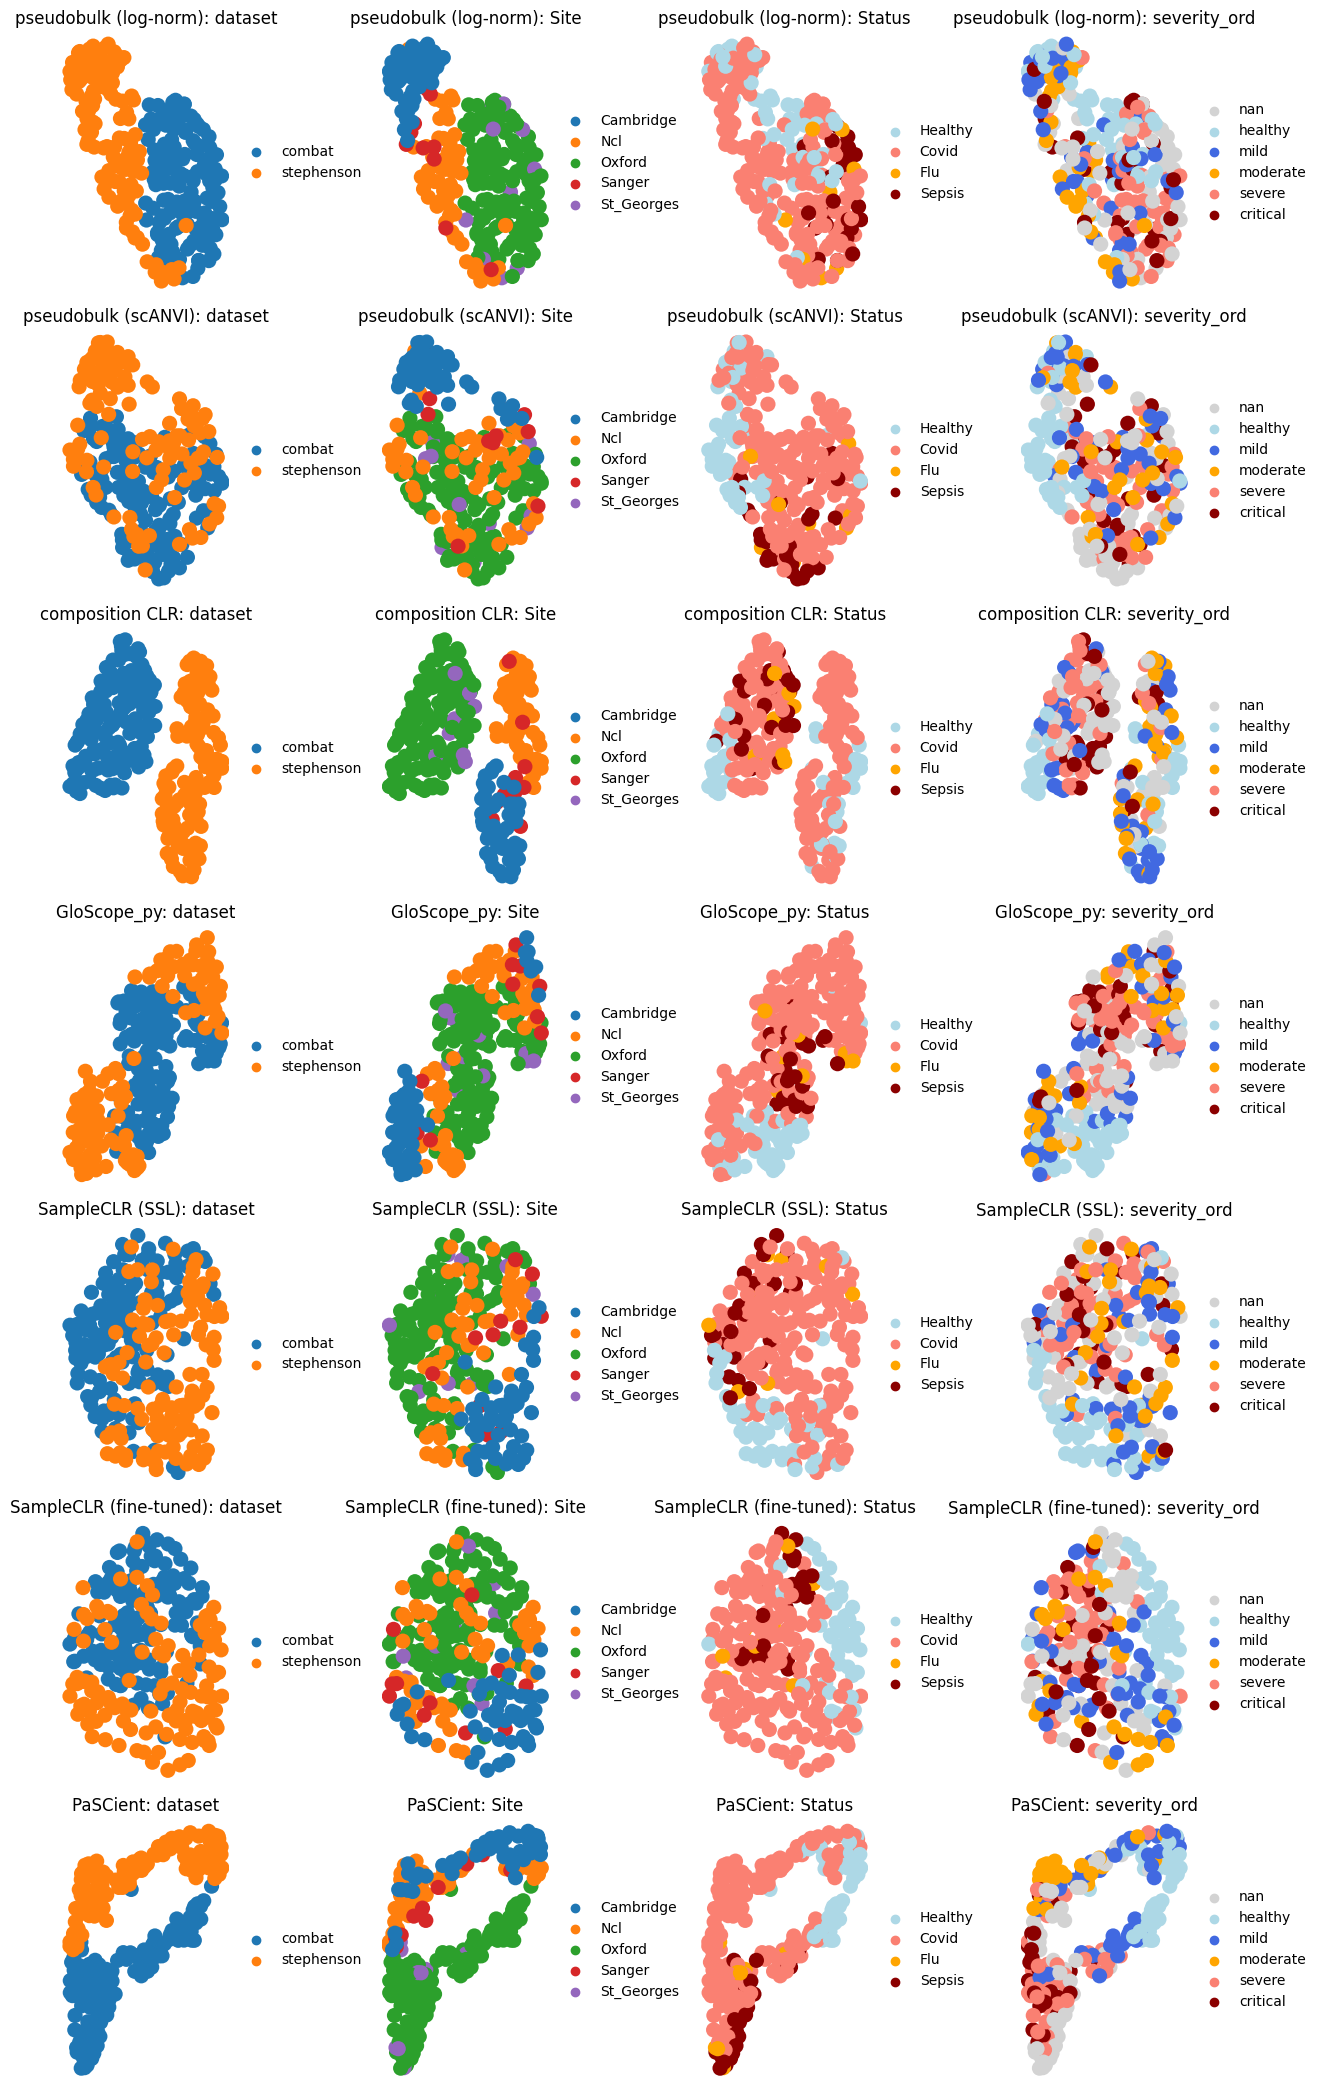

In [19]:
# UMAP grid: 4 covariates per representation (dataset, Site, Status, severity)
PANEL_COVARIATES = ["dataset", "Site", "Status", "severity_ord"]

fig, axes = plt.subplots(len(REPS), len(PANEL_COVARIATES),
                         figsize=(3.2 * len(PANEL_COVARIATES), 3.0 * len(REPS)),
                         squeeze=False)
for row, (rep, title) in enumerate(REPS):
    meta_adata.obsm["X_umap"] = meta_adata.obsm[f"X_umap_{rep}"]
    for col, cov in enumerate(PANEL_COVARIATES):
        sc.pl.umap(meta_adata, color=cov, ax=axes[row, col], show=False,
                   frameon=False, title=f"{title}: {cov}")
plt.tight_layout()
plt.show()
del meta_adata.obsm["X_umap"]


## 9. KNN benchmark — clinical info retention vs batch mixing

`patpy.tl.evaluation.knn_prediction_score` runs a precomputed-distance KNN per `(representation, covariate)` and returns F1 (classification), Spearman ρ (regression / ranking).

- **relevant** (clinical info retention): `severity_idx`, `Status`, `outcome_bin`, `TimeSinceOnset`.
- **technical** (batch mixing): `Site`, `dataset` — scores reversed so higher = better mixing.

Several columns in `combat_stephenson` are stringified categories (`'12.0'`, `'1.0'`, `'-1'`); we coerce them to `float64` so the underlying `KNeighborsRegressor` can multiply them.


In [20]:
from patpy.tl.evaluation import knn_prediction_score

def coerce_numeric(meta_adata, col):
    if col not in meta_adata.obs.columns:
        return
    s = meta_adata.obs[col]
    if s.dtype == np.float64:
        return
    s = s.astype(str).replace({"nan": np.nan, "NaN": np.nan, "None": np.nan, "<NA>": np.nan})
    meta_adata.obs[col] = pd.to_numeric(s, errors="coerce").astype(np.float64)

for col in ("TimeSinceOnset", "severity_idx", "outcome_bin", "Status_encoded"):
    coerce_numeric(meta_adata, col)

BENCHMARK_SCHEMA = {
    "relevant": {
        "severity_idx":   "ranking",
        "Status":         "classification",
        "outcome_bin":    "classification",
        "TimeSinceOnset": "regression",
    },
    "technical": {
        "Site":    "classification",
        "dataset": "classification",
    },
}

knn_df = knn_prediction_score(
    meta_adata,
    benchmark_schema=BENCHMARK_SCHEMA,
    n_neighbors=5,
    reverse_technical_score=True,
)
knn_df.to_csv(DATA_DIR / "benchmark_knn_scores.csv", index=False)
knn_pivot = knn_df.pivot_table(index="representation",
                               columns=["covariate_type", "covariate"],
                               values="score").round(3)
knn_pivot


covariate_type     relevant                                         technical  \
covariate            Status TimeSinceOnset outcome_bin severity_idx      Site   
representation                                                                  
composition_clr       0.447          0.226       0.000        0.341     0.372   
gloscope_py           0.448          0.448       0.276        0.573     0.517   
pascient              0.594          0.167       0.174        0.556     0.389   
pseudobulk_lognorm    0.288          0.365       0.001        0.417     0.498   
pseudobulk_scanvi     0.355          0.382       0.006        0.415     0.659   
sampleclr_ft          0.454          0.438       0.059        0.603     0.672   
sampleclr_ssl         0.380          0.454       0.135        0.513     0.672   

covariate_type              
covariate          dataset  
representation              
composition_clr      0.000  
gloscope_py          0.056  
pascient             0.024  
pseudobulk_lognorm   0.032  
pseudobulk_scanvi    0.235  
sampleclr_ft         0.249  
sampleclr_ssl        0.265

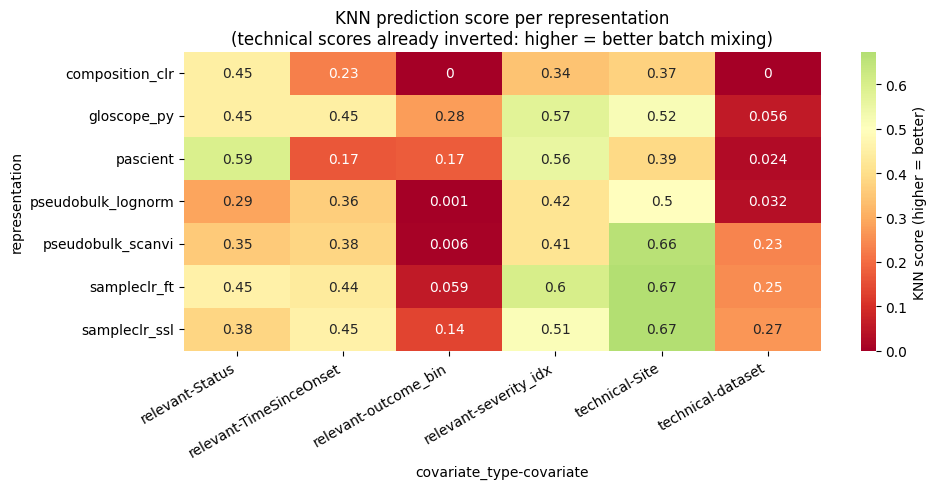

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(knn_pivot, annot=True, cmap="RdYlGn", center=0.5, ax=ax,
            cbar_kws={"label": "KNN score (higher = better)"})
ax.set_title("KNN prediction score per representation\n(technical scores already inverted: higher = better batch mixing)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


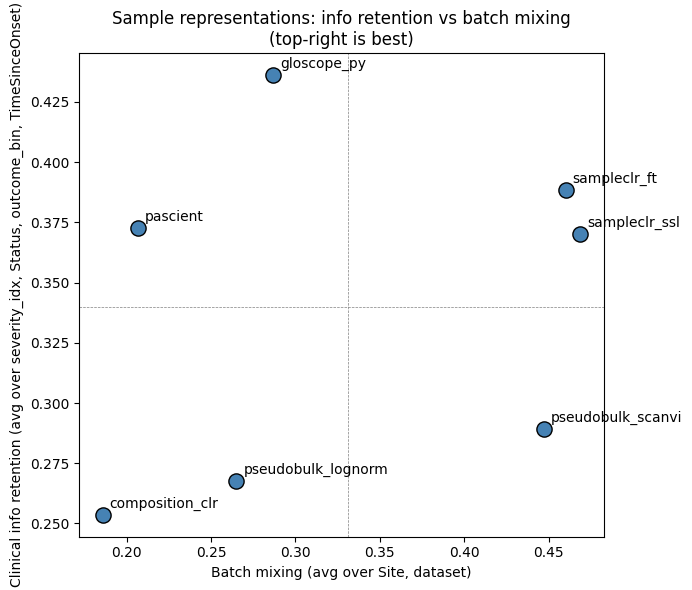

covariate_type,info_retention,batch_mixing
representation,,
gloscope_py,0.436,0.287
sampleclr_ft,0.388,0.460
pascient,0.373,0.207
sampleclr_ssl,0.370,0.468
pseudobulk_scanvi,0.289,0.447
pseudobulk_lognorm,0.268,0.265
composition_clr,0.254,0.186


In [22]:
# Aggregated info-retention vs batch-mixing scatter.
agg = (
    knn_df.groupby(["representation", "covariate_type"])["score"]
    .mean().unstack().rename(columns={"relevant": "info_retention",
                                      "technical": "batch_mixing"})
)
agg.to_csv(DATA_DIR / "benchmark_knn_aggregated.csv")

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(agg["batch_mixing"], agg["info_retention"], s=120, color="steelblue", edgecolor="black")
for rep, (x, y) in agg[["batch_mixing", "info_retention"]].iterrows():
    ax.annotate(rep, (x, y), xytext=(5, 5), textcoords="offset points", fontsize=10)
ax.set_xlabel("Batch mixing (avg over Site, dataset)")
ax.set_ylabel("Clinical info retention (avg over severity_idx, Status, outcome_bin, TimeSinceOnset)")
ax.set_title("Sample representations: info retention vs batch mixing\n(top-right is best)")
ax.axhline(agg["info_retention"].mean(), color="gray", lw=0.5, ls="--")
ax.axvline(agg["batch_mixing"].mean(), color="gray", lw=0.5, ls="--")
plt.tight_layout()
plt.show()
agg.round(3).sort_values("info_retention", ascending=False)


## 10. Trajectory benchmark — Spearman of pseudotime vs severity

We pin the diffusion-pseudotime root to a specific Healthy donor (`H00049-Ha001E-PBGa` — same as in earlier exploration) so the pseudotime direction is deterministic. `patpy.tl.evaluation.trajectory_correlation` computes diffusion pseudotime per representation and correlates it with `severity_idx`.


trajectory root: H00049-Ha001E-PBGa (Status= Healthy )


<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
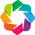

Computing diffmap for pseudobulk_lognorm
Computing diffmap for pseudobulk_scanvi
Computing diffmap for composition_clr
Computing diffmap for gloscope_py
Computing diffmap for sampleclr_ssl
Computing diffmap for sampleclr_ft
Computing diffmap for pascient


,correlation
sampleclr_ft,0.336967
pascient,0.238220
gloscope_py,0.189387
pseudobulk_scanvi,0.142391
sampleclr_ssl,0.099064
pseudobulk_lognorm,-0.069036
composition_clr,-0.097886


In [23]:
from patpy.tl.evaluation import trajectory_correlation

ROOT_SAMPLE = "H00049-Ha001E-PBGa"
assert ROOT_SAMPLE in meta_adata.obs.index, f"{ROOT_SAMPLE} not in meta_adata.obs"
print("trajectory root:", ROOT_SAMPLE,
      "(Status=", meta_adata.obs.loc[ROOT_SAMPLE, "Status"], ")")

traj_df = trajectory_correlation(
    meta_adata,
    root_sample=ROOT_SAMPLE,
    trajectory_variable="severity_idx",
    force=True,
)
traj_df.to_csv(DATA_DIR / "benchmark_trajectory_correlation.csv")
traj_df


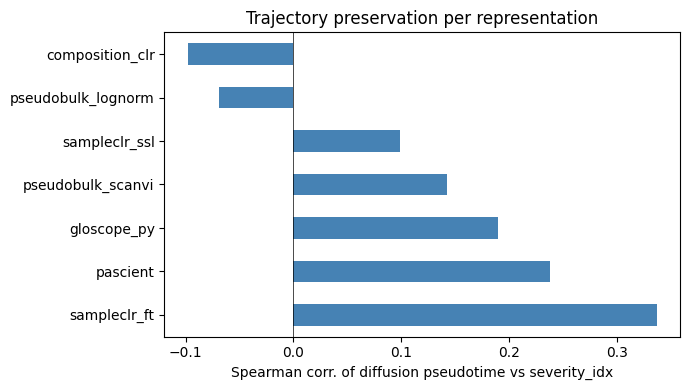

In [24]:
fig, ax = plt.subplots(figsize=(7, 4))
traj_df.plot.barh(y="correlation", ax=ax, legend=False, color="steelblue")
ax.set_xlabel("Spearman corr. of diffusion pseudotime vs severity_idx")
ax.set_title("Trajectory preservation per representation")
ax.axvline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()


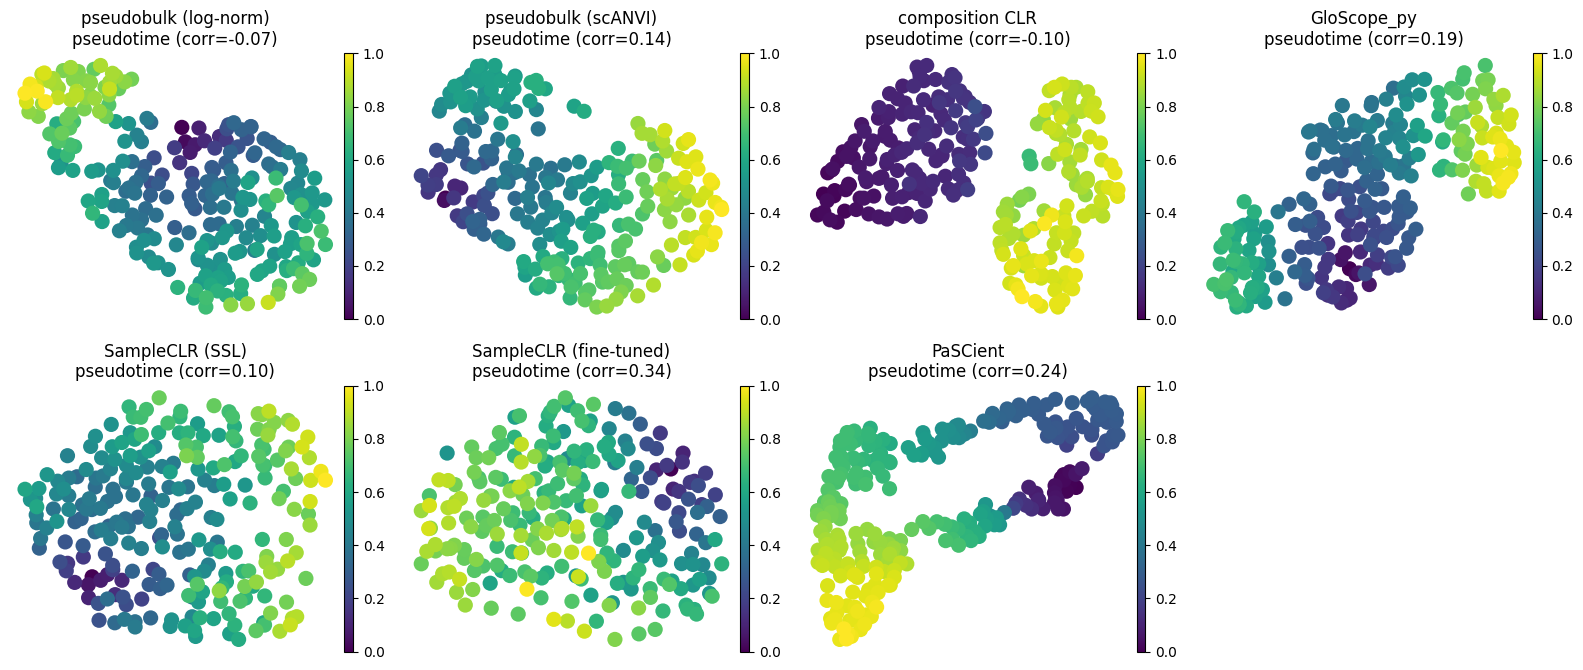

In [25]:
# Per-rep UMAP coloured by that rep's diffusion pseudotime.
n = len(REPS); ncols = 4; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4.0 * ncols, 3.4 * nrows), squeeze=False)
for i, (rep, title) in enumerate(REPS):
    r, c = divmod(i, ncols)
    pt_col = f"{rep}_dpt_pseudotime"
    if pt_col not in meta_adata.obs.columns:
        axes[r, c].set_visible(False); continue
    meta_adata.obsm["X_umap"] = meta_adata.obsm[f"X_umap_{rep}"]
    sc.pl.umap(meta_adata, color=pt_col, ax=axes[r, c], show=False, frameon=False,
               cmap="viridis", title=f"{title}\npseudotime (corr={traj_df.loc[rep,'correlation']:.2f})")
for j in range(n, nrows * ncols):
    axes[j // ncols, j % ncols].set_visible(False)
plt.tight_layout(); plt.show()
del meta_adata.obsm["X_umap"]


## 11. Cluster every representation, ARI vs Site & Status

Running leiden on each rep's neighbor graph gives clusters whose agreement (Adjusted Rand Index) with `Status` measures clinical-signal recovery, while ARI with `Site` measures batch leakage. Higher ARI vs Status = better, lower ARI vs Site = better.


In [26]:
from sklearn.metrics import adjusted_rand_score

ari_rows = []
for rep, _ in REPS:
    nn_key = f"{rep}_neighbors"
    cluster_col = f"{rep}_leiden"
    sc.tl.leiden(meta_adata, neighbors_key=nn_key, resolution=0.5,
                 random_state=SEED, key_added=cluster_col)
    clusters = meta_adata.obs[cluster_col].values
    ari_rows.append({
        "representation": rep,
        "ARI_vs_Status": adjusted_rand_score(meta_adata.obs["Status"].astype(str), clusters),
        "ARI_vs_Site":   adjusted_rand_score(meta_adata.obs["Site"].astype(str), clusters),
        "n_clusters":    int(meta_adata.obs[cluster_col].nunique()),
    })

ari_df = pd.DataFrame(ari_rows).set_index("representation")
ari_df.to_csv(DATA_DIR / "benchmark_clustering_ari.csv")
ari_df.round(3)


,ARI_vs_Status,ARI_vs_Site,n_clusters
representation,,,
pseudobulk_lognorm,0.026,0.526,4
pseudobulk_scanvi,0.058,0.216,4
composition_clr,0.075,0.644,4
gloscope_py,0.048,0.237,4
sampleclr_ssl,0.026,0.110,3
sampleclr_ft,0.200,0.172,2
pascient,0.090,0.228,7


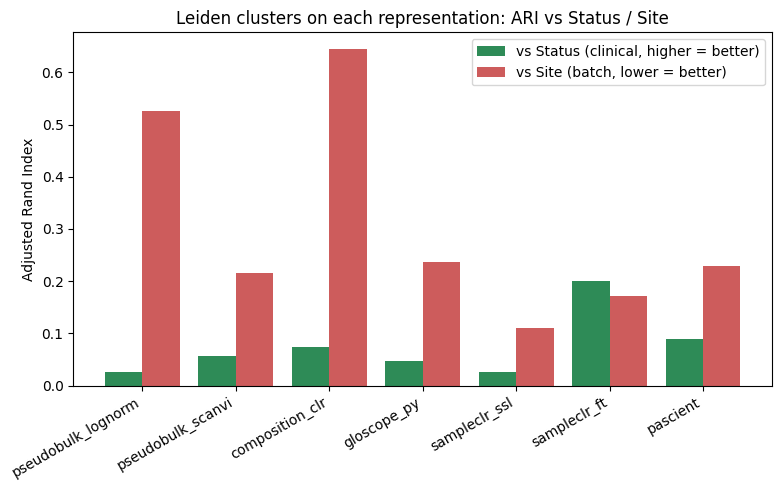

In [27]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(ari_df))
w = 0.4
ax.bar(x - w/2, ari_df["ARI_vs_Status"], w, label="vs Status (clinical, higher = better)", color="seagreen")
ax.bar(x + w/2, ari_df["ARI_vs_Site"],   w, label="vs Site (batch, lower = better)",       color="indianred")
ax.set_xticks(x)
ax.set_xticklabels(ari_df.index, rotation=30, ha="right")
ax.set_ylabel("Adjusted Rand Index")
ax.set_title("Leiden clusters on each representation: ARI vs Status / Site")
ax.legend()
ax.axhline(0, color="black", lw=0.5)
plt.tight_layout(); plt.show()


## 12. For the best trajectory rep: gene + cell-type-proportion correlation with pseudotime

We pick whichever representation tops the trajectory benchmark. Per donor we have a pseudotime; we lift it to per-cell (every cell of donor *d* gets *d*'s pseudotime), then Spearman-correlate every gene's log-norm expression with pseudotime. Cell-type proportions are correlated at the donor level.


In [28]:
from scipy import stats as scstats
from scipy.sparse import issparse

best_rep = traj_df.index[0]
best_pt_col = f"{best_rep}_dpt_pseudotime"
print(f"best trajectory representation: {best_rep}  (corr={traj_df.iloc[0, 0]:.3f})")

# Cell-type proportions per donor (raw, not CLR) → correlate each cell type with pseudotime
ct_props = pd.crosstab(adata.obs[info.sample_key], adata.obs[info.cell_type_key], normalize="index")
ct_props = ct_props.reindex(meta_adata.obs.index)
pt_per_donor = meta_adata.obs[best_pt_col].astype(float)

ct_corr_rows = []
for ct in ct_props.columns:
    rho, p = scstats.spearmanr(ct_props[ct].values, pt_per_donor.values, nan_policy="omit")
    ct_corr_rows.append({"cell_type": ct, "spearman_r": rho, "p": p})
ct_corr = pd.DataFrame(ct_corr_rows).sort_values("spearman_r", ascending=False)
ct_corr.to_csv(DATA_DIR / f"pseudotime_celltype_correlation_{best_rep}.csv", index=False)
ct_corr.round(3)


best trajectory representation: sampleclr_ft  (corr=0.337)


,cell_type,spearman_r,p
13,Plasmablast,0.446,0.000
7,HSC,0.245,0.000
15,cMono,0.174,0.006
0,B,0.133,0.035
12,PLT,0.123,0.052
14,RET,0.058,0.362
8,Lymph_prolif,0.038,0.549
4,DN,0.024,0.702
5,DP,0.015,0.815
1,CD4,-0.089,0.159


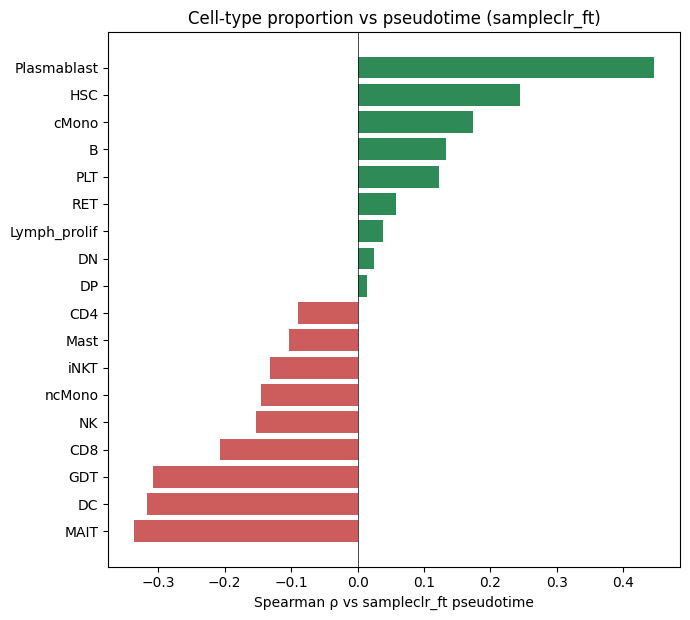

In [29]:
fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(ct_corr))))
ct_plot = ct_corr.set_index("cell_type")["spearman_r"].sort_values()
colors = ["indianred" if v < 0 else "seagreen" for v in ct_plot.values]
ax.barh(ct_plot.index, ct_plot.values, color=colors)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel(f"Spearman ρ vs {best_rep} pseudotime")
ax.set_title(f"Cell-type proportion vs pseudotime ({best_rep})")
plt.tight_layout(); plt.show()


In [30]:
# Gene correlation with pseudotime: lift donor-level pseudotime to per-cell, then
# Spearman-correlate each gene. To keep the run light we vectorise via Pearson on
# rank-transformed pseudotime (equivalent to Spearman) and only output the top hits.
pt_per_cell = adata.obs[info.sample_key].map(pt_per_donor.to_dict()).astype(float).values
keep = ~np.isnan(pt_per_cell)
pt_kept = pt_per_cell[keep]
pt_rank = scstats.rankdata(pt_kept).astype(np.float32)
pt_rank -= pt_rank.mean(); pt_rank /= pt_rank.std()

# Pearson(X_rank, pt_rank) per gene == Spearman.
X = adata.layers[LOGNORM_LAYER]
X = X[keep]
n_cells = X.shape[0]
gene_means = (X.sum(axis=0) / n_cells).A1 if issparse(X) else X.mean(axis=0)
# Compute correlation column-by-column, in chunks.
corrs = np.zeros(adata.n_vars, dtype=np.float32)
chunk = 500
for s in range(0, adata.n_vars, chunk):
    e = min(s + chunk, adata.n_vars)
    Xs = X[:, s:e]
    if issparse(Xs):
        Xs = Xs.toarray()
    Xs = Xs.astype(np.float32)
    Xs_rank = np.empty_like(Xs)
    for j in range(Xs.shape[1]):
        Xs_rank[:, j] = scstats.rankdata(Xs[:, j])
    Xs_rank -= Xs_rank.mean(axis=0)
    std = Xs_rank.std(axis=0); std[std == 0] = 1
    Xs_rank /= std
    corrs[s:e] = (Xs_rank * pt_rank[:, None]).sum(axis=0) / n_cells

gene_corr = pd.DataFrame({"gene": adata.var_names, "spearman_r": corrs})
gene_corr.to_csv(DATA_DIR / f"pseudotime_gene_correlation_{best_rep}.csv", index=False)
top_pos = gene_corr.nlargest(15, "spearman_r")
top_neg = gene_corr.nsmallest(15, "spearman_r")
print("Top + correlated genes:"); print(top_pos.to_string(index=False))
print("\nTop − correlated genes:"); print(top_neg.to_string(index=False))


Top + correlated genes:
           gene  spearman_r
ENSG00000137959    0.320921
ENSG00000126709    0.294294
ENSG00000187608    0.256602
ENSG00000157601    0.253494
ENSG00000165949    0.244795
ENSG00000119917    0.238540
ENSG00000185507    0.210303
ENSG00000133106    0.200131
ENSG00000134321    0.191953
ENSG00000089127    0.191411
ENSG00000185745    0.190601
ENSG00000120885    0.183259
ENSG00000188313    0.172435
ENSG00000142089    0.166072
ENSG00000125148    0.164731

Top − correlated genes:
           gene  spearman_r
ENSG00000198727   -0.227745
ENSG00000184009   -0.132129
ENSG00000167996   -0.126268
ENSG00000170345   -0.112107
ENSG00000181163   -0.097169
ENSG00000075624   -0.088583
ENSG00000168685   -0.082137
ENSG00000111796   -0.078349
ENSG00000113088   -0.077373
ENSG00000196154   -0.073358
ENSG00000271503   -0.070501
ENSG00000169508   -0.069499
ENSG00000196230   -0.068430
ENSG00000005022   -0.065701
ENSG00000171476   -0.065133


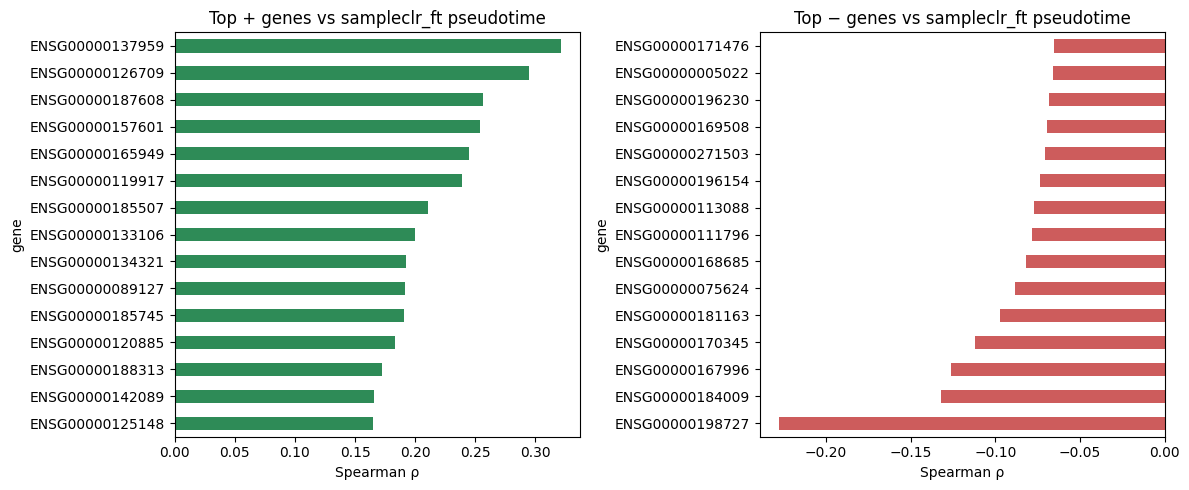

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_pos.set_index("gene")["spearman_r"].sort_values().plot.barh(ax=axes[0], color="seagreen")
axes[0].set_title(f"Top + genes vs {best_rep} pseudotime")
axes[0].set_xlabel("Spearman ρ")
top_neg.set_index("gene")["spearman_r"].sort_values().plot.barh(ax=axes[1], color="indianred")
axes[1].set_title(f"Top − genes vs {best_rep} pseudotime")
axes[1].set_xlabel("Spearman ρ")
plt.tight_layout(); plt.show()


## 13. Marker genes for SampleCLR (fine-tuned) clusters

Lift each donor's `sampleclr_ft_leiden` cluster down to its cells, then run `sc.tl.rank_genes_groups` on the cell-level adata. Each cluster's top markers tell us what makes those donors transcriptionally distinct in the supervised representation.


In [32]:
sclr_ft_clusters = meta_adata.obs["sampleclr_ft_leiden"]
adata.obs["sampleclr_ft_cluster"] = (
    adata.obs[info.sample_key].map(sclr_ft_clusters).astype("category")
)
print(adata.obs["sampleclr_ft_cluster"].value_counts())

sc.tl.rank_genes_groups(
    adata, groupby="sampleclr_ft_cluster",
    method="wilcoxon", layer=LOGNORM_LAYER, n_genes=25,
)


sampleclr_ft_cluster
0    1028526
1     370909
Name: count, dtype: int64


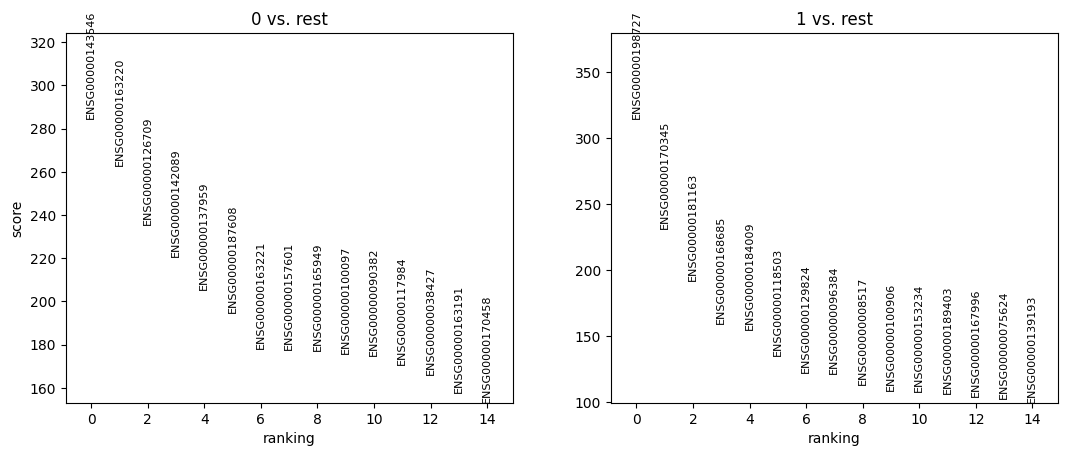

In [33]:
sc.pl.rank_genes_groups(adata, n_genes=15, sharey=False)


In [34]:
# Top-5 markers per cluster as a tidy table
markers_records = []
groups = adata.uns["rank_genes_groups"]["names"].dtype.names
for g in groups:
    for i in range(5):
        markers_records.append({
            "cluster": g,
            "rank": i + 1,
            "gene": adata.uns["rank_genes_groups"]["names"][g][i],
            "logfc": float(adata.uns["rank_genes_groups"]["logfoldchanges"][g][i]),
            "pval_adj": float(adata.uns["rank_genes_groups"]["pvals_adj"][g][i]),
        })
markers_df = pd.DataFrame(markers_records)
markers_df.to_csv(DATA_DIR / "sampleclr_ft_cluster_markers.csv", index=False)
markers_df.head(25)


,cluster,rank,gene,logfc,pval_adj
0,0,1,ENSG00000143546,2.546513,0.0
1,0,2,ENSG00000163220,2.326752,0.0
2,0,3,ENSG00000126709,1.949894,0.0
3,0,4,ENSG00000142089,1.572799,0.0
4,0,5,ENSG00000137959,2.896182,0.0
5,1,1,ENSG00000198727,1.179629,0.0
6,1,2,ENSG00000170345,1.246917,0.0
7,1,3,ENSG00000181163,1.095304,0.0
8,1,4,ENSG00000168685,1.426973,0.0
9,1,5,ENSG00000184009,0.518822,0.0


## 14. Persist the final `meta_adata`


In [35]:
META_ADATA_FINAL = DATA_DIR / "stephenson_combat_meta_adata.h5ad"
np.savez(DATA_DIR / "gloscope_py_distances.npz",
         distances=distances_gloscope, samples=np.asarray(gs.samples))

meta_adata.write_h5ad(META_ADATA_FINAL)
print("final meta_adata:", META_ADATA_FINAL)
print("  obsm keys :", sorted(meta_adata.obsm.keys()))
print("  uns reps  :", meta_adata.uns.get("sample_representations"))
print("  benchmarks:",
      "benchmark_knn_scores.csv,",
      "benchmark_knn_aggregated.csv,",
      "benchmark_trajectory_correlation.csv,",
      "benchmark_clustering_ari.csv,",
      f"pseudotime_celltype_correlation_{best_rep}.csv,",
      f"pseudotime_gene_correlation_{best_rep}.csv,",
      "sampleclr_ft_cluster_markers.csv")
print("  models    :", *(p.name for p in [
    MODELS_DIR / "sampleclr_ssl_state.pt",
    MODELS_DIR / "sampleclr_ft_state.pt",
    MODELS_DIR / "pascient_state.pt",
]))


final meta_adata: /ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/docs/notebooks/data/stephenson_combat/stephenson_combat_meta_adata.h5ad
  obsm keys : ['X_composition_clr', 'X_composition_clr_diffmap', 'X_diffmap', 'X_gloscope_py', 'X_gloscope_py_diffmap', 'X_pascient', 'X_pascient_diffmap', 'X_pseudobulk_lognorm', 'X_pseudobulk_lognorm_diffmap', 'X_pseudobulk_scanvi', 'X_pseudobulk_scanvi_diffmap', 'X_sampleclr_ft', 'X_sampleclr_ft_diffmap', 'X_sampleclr_ssl', 'X_sampleclr_ssl_diffmap', 'X_umap_composition_clr', 'X_umap_gloscope_py', 'X_umap_pascient', 'X_umap_pseudobulk_lognorm', 'X_umap_pseudobulk_scanvi', 'X_umap_sampleclr_ft', 'X_umap_sampleclr_ssl', 'composition_clr', 'composition_clr_distances', 'gloscope_py', 'gloscope_py_distances', 'pascient', 'pascient_distances', 'pseudobulk_lognorm', 'pseudobulk_lognorm_distances', 'pseudobulk_scanvi', 'pseudobulk_scanvi_distances', 'sampleclr_ft', 'sampleclr_ft_distances', 'sampleclr_ssl', 'sampleclr_ssl_distances']
  uns reps 